In [2]:
import os
import numpy as np
import cv2
import zipfile
import requests
import glob as glob

import tensorflow_hub as hub
import matplotlib
import matplotlib.pyplot as plt
import warnings
import logging
import absl

#filter absl warning
warnings.filterwarnings("ignore", module="absl")

#capture all warnings in logging system
logging.captureWarnings(True)

#set absl logger level to 'error' to suppress warnings
absl_logger = logging.getLogger("absl")
absl_logger.setLevel(logging.ERROR)

os.environ['TP_CPP_MIN_LOG_LEVEL'] = '2'


In [6]:
#download images
def download_file(url, save_name):
    url = url
    file = requests.get(url)

    open(save_name, 'wb').write(file.content)

In [7]:
def unzip(zip_file=None):
    try:
        with zipfile.ZipFile(zip_file) as z:
            z.extractall("./")
            print("Extracted all")
    except:
        print("Invalid file")

In [8]:
download_file(
    'https://www.dropbox.com/s/h7l1lmhvga6miyo/object_detection_images.zip?dl=1',
    'object_detection_images.zip'
    )

unzip(zip_file='object_detection_images.zip')

Extracted all


In [9]:
#display images
image_paths = sorted(glob.glob('object_detection_images' + '/*.png'))

for idx in range(len(image_paths)):
    print(image_paths[idx])

object_detection_images\dog_bicycle_car.png
object_detection_images\elephants.png
object_detection_images\home_interior.png
object_detection_images\place_setting.png


In [12]:
def load_image(path):

    image = cv2.imread(path)

    #convert to BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #add batch dimension
    image = np.expand_dims(image, axis=0)

    return image

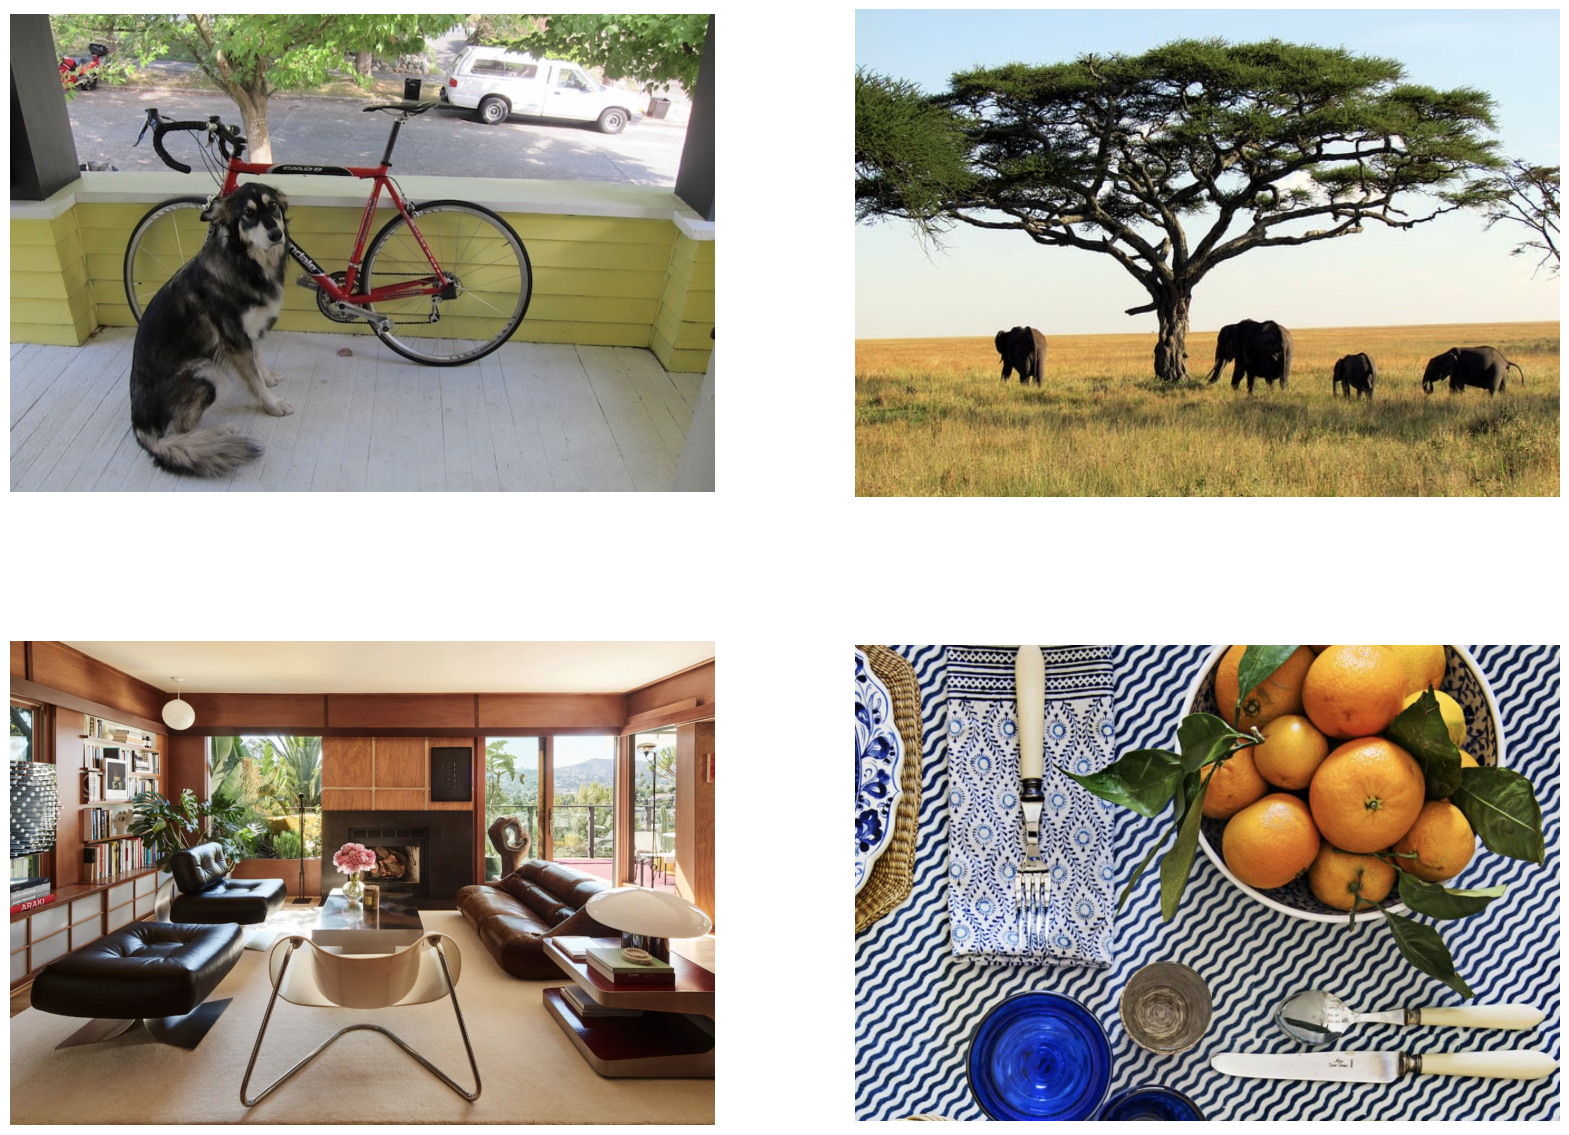

In [13]:
images = []
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))

idx = 0
for axis in ax.flat:
    image = load_image(image_paths[idx])
    images.append(image)
    axis.imshow(image[0])
    axis.axis('off')
    idx+=1

In [14]:
#define dictionary
class_index =  \
{
         1: 'person',
         2: 'bicycle',
         3: 'car',
         4: 'motorcycle',
         5: 'airplane',
         6: 'bus',
         7: 'train',
         8: 'truck',
         9: 'boat',
         10: 'traffic light',
         11: 'fire hydrant',
         13: 'stop sign',
         14: 'parking meter',
         15: 'bench',
         16: 'bird',
         17: 'cat',
         18: 'dog',
         19: 'horse',
         20: 'sheep',
         21: 'cow',
         22: 'elephant',
         23: 'bear',
         24: 'zebra',
         25: 'giraffe',
         27: 'backpack',
         28: 'umbrella',
         31: 'handbag',
         32: 'tie',
         33: 'suitcase',
         34: 'frisbee',
         35: 'skis',
         36: 'snowboard',
         37: 'sports ball',
         38: 'kite',
         39: 'baseball bat',
         40: 'baseball glove',
         41: 'skateboard',
         42: 'surfboard',
         43: 'tennis racket',
         44: 'bottle',
         46: 'wine glass',
         47: 'cup',
         48: 'fork',
         49: 'knife',
         50: 'spoon',
         51: 'bowl',
         52: 'banana',
         53: 'apple',
         54: 'sandwich',
         55: 'orange',
         56: 'broccoli',
         57: 'carrot',
         58: 'hot dog',
         59: 'pizza',
         60: 'donut',
         61: 'cake',
         62: 'chair',
         63: 'couch',
         64: 'potted plant',
         65: 'bed',
         67: 'dining table',
         70: 'toilet',
         72: 'tv',
         73: 'laptop',
         74: 'mouse',
         75: 'remote',
         76: 'keyboard',
         77: 'cell phone',
         78: 'microwave',
         79: 'oven',
         80: 'toaster',
         81: 'sink',
         82: 'refrigerator',
         84: 'book',
         85: 'clock',
         86: 'vase',
         87: 'scissors',
         88: 'teddy bear',
         89: 'hair drier',
         90: 'toothbrush'
}

In [19]:
#use COLOR_IDS to map each class with unique RGB color
R = np.array(np.arange(96, 256, 32))
G = np.roll(R, 1)
B = np.roll(R, 2)
print(R, G, B)
COLOR_IDS = np.array(np.meshgrid(R, G, B)).T.reshape(-1, 3)
print(COLOR_IDS)

[ 96 128 160 192 224] [224  96 128 160 192] [192 224  96 128 160]
[[ 96 224 192]
 [ 96  96 192]
 [ 96 128 192]
 [ 96 160 192]
 [ 96 192 192]
 [128 224 192]
 [128  96 192]
 [128 128 192]
 [128 160 192]
 [128 192 192]
 [160 224 192]
 [160  96 192]
 [160 128 192]
 [160 160 192]
 [160 192 192]
 [192 224 192]
 [192  96 192]
 [192 128 192]
 [192 160 192]
 [192 192 192]
 [224 224 192]
 [224  96 192]
 [224 128 192]
 [224 160 192]
 [224 192 192]
 [ 96 224 224]
 [ 96  96 224]
 [ 96 128 224]
 [ 96 160 224]
 [ 96 192 224]
 [128 224 224]
 [128  96 224]
 [128 128 224]
 [128 160 224]
 [128 192 224]
 [160 224 224]
 [160  96 224]
 [160 128 224]
 [160 160 224]
 [160 192 224]
 [192 224 224]
 [192  96 224]
 [192 128 224]
 [192 160 224]
 [192 192 224]
 [224 224 224]
 [224  96 224]
 [224 128 224]
 [224 160 224]
 [224 192 224]
 [ 96 224  96]
 [ 96  96  96]
 [ 96 128  96]
 [ 96 160  96]
 [ 96 192  96]
 [128 224  96]
 [128  96  96]
 [128 128  96]
 [128 160  96]
 [128 192  96]
 [160 224  96]
 [160  96  96]
 [16

In [20]:
#model inference
EfficientDet  = {'EfficientDet D0 512x512'   : 'https://tfhub.dev/tensorflow/efficientdet/d0/1',
                 'EfficientDet D1 640x640'   : 'https://tfhub.dev/tensorflow/efficientdet/d1/1',
                 'EfficientDet D2 768x768'   : 'https://tfhub.dev/tensorflow/efficientdet/d2/1',
                 'EfficientDet D3 896x896'   : 'https://tfhub.dev/tensorflow/efficientdet/d3/1',
                 'EfficientDet D4 1024x1024' : 'https://tfhub.dev/tensorflow/efficientdet/d4/1',
                 'EfficientDet D5 1280x1280' : 'https://tfhub.dev/tensorflow/efficientdet/d5/1',
                 'EfficientDet D6 1280x1280' : 'https://tfhub.dev/tensorflow/efficientdet/d6/1',
                 'EfficientDet D7 1536x1536' : 'https://tfhub.dev/tensorflow/efficientdet/d7/1'
                }

In [21]:
model_url = EfficientDet['EfficientDet D4 1024x1024']

print('loading model', model_url)
od_model = hub.load(model_url)

print('\nmodel loaded!')

loading model https://tfhub.dev/tensorflow/efficientdet/d4/1




model loaded!


In [22]:
#call model #model returnd detection result in form of dictionary
results = od_model(images[0])

In [24]:
#inspect result
#conevrt dictionary values to numpy array
results = {key:value.numpy() for key, value in results.items()} 

In [25]:
for key in results:
    print(key)

raw_detection_boxes
detection_multiclass_scores
detection_classes
detection_boxes
raw_detection_scores
num_detections
detection_anchor_indices
detection_scores


In [27]:
print('Num Raw Detections:', (len(results['raw_detection_scores'][0])))
print('Num Detections:', (results['num_detections'][0]).astype(int))

Num Raw Detections: 196416
Num Detections: 100


In [28]:
#print scores, classes and bounding boxes for the detections
num_dets = (results['num_detections'][0]).astype(int)

print('\nDetection Scores: \n\n', results['detection_scores'][0][0:num_dets])
print('\nDetection Classes: \n\n', results['detection_classes'][0][0:num_dets])
print('\nDetection Boxes: \n\n', results['detection_boxes'][0][0:num_dets])


Detection Scores: 

 [0.90533066 0.8789406  0.7202935  0.35475978 0.28056234 0.1785026
 0.15169771 0.1490605  0.14454062 0.1358348  0.12682496 0.11745204
 0.10780203 0.10151791 0.10052415 0.09747405 0.09338368 0.09328791
 0.090955   0.0878429  0.0829491  0.08292704 0.08103948 0.07869293
 0.07779159 0.07524483 0.07296467 0.07162403 0.07000022 0.06879056
 0.06795251 0.06612464 0.06535597 0.0644578  0.06108105 0.05956696
 0.05944298 0.05919548 0.05845254 0.05823716 0.05798653 0.05783079
 0.05775054 0.05753618 0.0574718  0.05707676 0.05703336 0.05582752
 0.05510031 0.05509661 0.05461616 0.05444636 0.05370711 0.0533554
 0.05323369 0.05098717 0.05098488 0.04960291 0.04953315 0.04781683
 0.04760983 0.04728271 0.04687167 0.04676605 0.04627279 0.04581982
 0.04572152 0.04525171 0.04518341 0.04492664 0.04447949 0.043266
 0.04299232 0.04221693 0.04141534 0.04104362 0.04087303 0.04061302
 0.04059264 0.0402757  0.04010023 0.03925974 0.03919704 0.03858818
 0.03826004 0.03815688 0.0380402  0.03789712

In [ ]:
#post processing